# 📊 Civilizational Environment & Physical Analysis (Layer 1)

Ce notebook présente l'**Analyse Exploratoire des Données (EDA)** et la validation des **9 indicateurs cibles** pour notre simulation de civilisation.

L'objectif de cette étude est d'analyser comment les facteurs physiques de la planète (Couche 1 : Climat, Topographie, Hydrologie et Géologie) régissent la viabilité de base de l'environnement humain.

## 🌍 Les 9 Cibles de Simulation de la Couche 1
1. **🌾 Rendement Agricole (Yield)** : Quantité de calories produites par hectare.
2. **💧 Stress Hydrique (Sécheresse)** : Indice de pénurie d'eau douce (0 à 1).
3. **🌲 Dynamique des Biomes (Désertification)** : Classification climatique de Koppen-Geiger.
4. **🌪️ Risque d'Inondation** : Risque topographique et hydrologique de crue.
5. **♻️ Taux de Dégradation du Sol** : Épuisement des nutriments (N, P, K) par culture intensive.
6. **🐺 Densité de la Faune** : Gibier disponible (Chasse) & Menace de grands prédateurs.
7. **🦟 Prolifération Parasitaire (Maladies)** : Index de vecteur de pathogènes (Malaria/Dengue).
8. **🌡️ Anomalie Thermique (Îlot de Chaleur)** : Hausse thermique induite par déforestation.
9. **🌊 Probabilité d'Érosion** : Recul des terres côtières/fluviales par action hydraulique.

## ⚙️ Initialisation du Notebook

Chargement des dépendances standard de data science et configuration du style graphique.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Ajouter le dossier parent au path pour importer le moteur physique
sys.path.append(os.path.abspath('..'))
from layer1_engine import Layer1Engine

# Style des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

CLEAN_DIR = "data/cleaned"
print("Notebook initialisé avec succès ! ✅")

Notebook initialisé avec succès ! ✅


## 📦 Chargement et Fusion des Données

Nous fusionnons les séries temporelles climatiques et agricoles nettoyées pour analyser les dépendances globales.

In [2]:
print("Chargement des fichiers...")
df_prod = pd.read_csv(f"{CLEAN_DIR}/production_cultures.csv")
df_temp = pd.read_csv(f"{CLEAN_DIR}/mean_temperature.csv").rename(columns={'Valeur': 'Temperature_C'})
df_precip = pd.read_csv(f"{CLEAN_DIR}/precipitations.csv").rename(columns={'Valeur': 'Precipitations_mm'})
df_fert = pd.read_csv(f"{CLEAN_DIR}/fertilizers_nutrient.csv")
df_pest = pd.read_csv(f"{CLEAN_DIR}/pesticides.csv")
df_sols = pd.read_csv(f"{CLEAN_DIR}/bilan_nutritif_sols.csv").rename(columns={'Valeur': 'Bilan_sols_kgha'})

# 1. Filtrer le rendement agricole
df_yield = df_prod[df_prod['Element'] == 'Rendement'].copy().rename(columns={'Valeur': 'Rendement_kgha'})
df_yield = df_yield[(df_yield['Rendement_kgha'] <= 100000) & (df_yield['Rendement_kgha'] > 0)]

# 2. Agrégations
df_fert_agg = df_fert.groupby(['Pays', 'Annee'])['Valeur'].sum().reset_index().rename(columns={'Valeur': 'Engrais_kgha'})
df_pest_agg = df_pest.groupby(['Pays', 'Annee'])['Valeur'].sum().reset_index().rename(columns={'Valeur': 'Pesticides_kgha'})
df_temp_agg = df_temp.groupby(['Pays', 'Annee'])['Temperature_C'].mean().reset_index()
df_precip_agg = df_precip.groupby(['Pays', 'Annee'])['Precipitations_mm'].mean().reset_index()

# 3. Fusion master
df_master = pd.merge(df_yield[['Pays', 'Produit', 'Annee', 'Rendement_kgha']], df_sols[['Pays', 'Produit', 'Annee', 'Bilan_sols_kgha']], on=['Pays', 'Produit', 'Annee'], how='left')
df_master = pd.merge(df_master, df_temp_agg, on=['Pays', 'Annee'], how='left')
df_master = pd.merge(df_master, df_precip_agg, on=['Pays', 'Annee'], how='left')
df_master = pd.merge(df_master, df_fert_agg, on=['Pays', 'Annee'], how='left')
df_master = pd.merge(df_master, df_pest_agg, on=['Pays', 'Annee'], how='left')

df_master = df_master.dropna(subset=['Temperature_C', 'Precipitations_mm', 'Rendement_kgha'])
print(f"Master dataset fusionné : {df_master.shape[0]:,} lignes et {df_master.shape[1]} colonnes.")

Chargement des fichiers...
Master dataset fusionné : 152,928 lignes et 9 colonnes.


## 📈 Distributions et Corrélations des Variables Environnementales

Visualisation de la répartition de nos variables et de leurs corrélations linéaires.

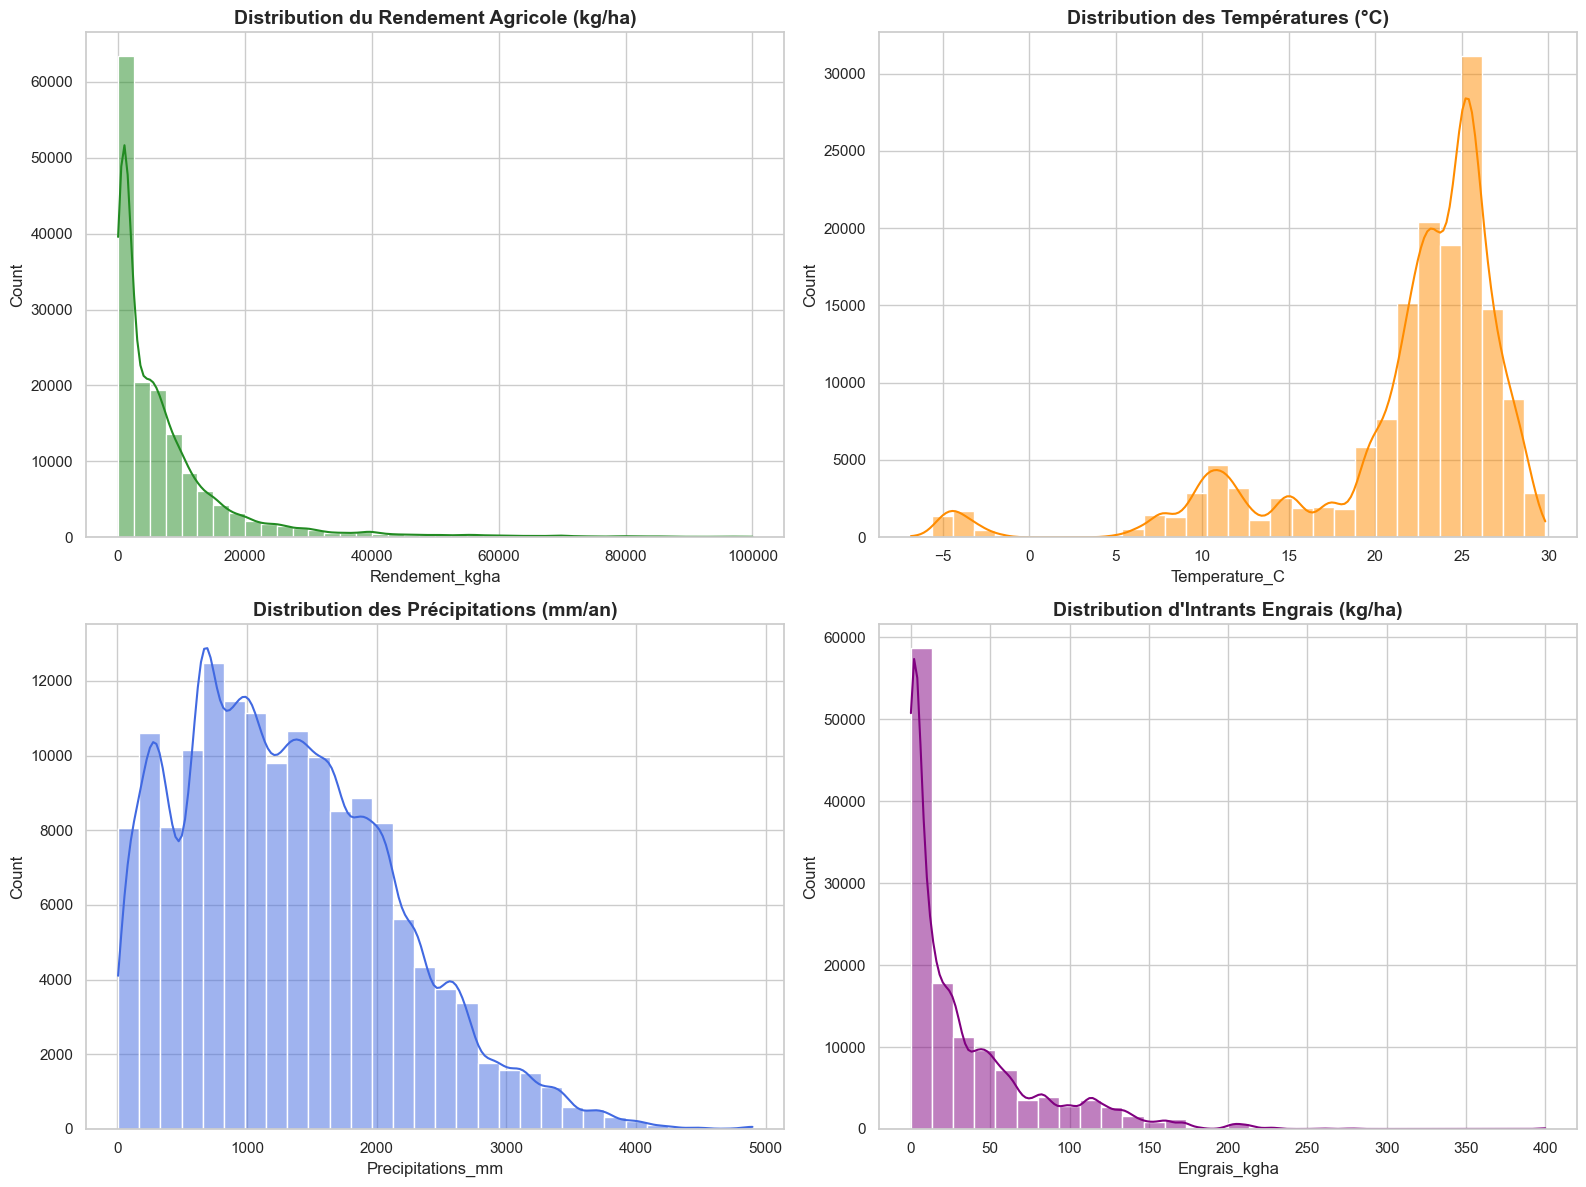

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df_master['Rendement_kgha'], bins=40, kde=True, ax=axes[0,0], color='forestgreen')
axes[0,0].set_title("Distribution du Rendement Agricole (kg/ha)")

sns.histplot(df_master['Temperature_C'], bins=30, kde=True, ax=axes[0,1], color='darkorange')
axes[0,1].set_title("Distribution des Températures (°C)")

sns.histplot(df_master['Precipitations_mm'], bins=30, kde=True, ax=axes[1,0], color='royalblue')
axes[1,0].set_title("Distribution des Précipitations (mm/an)")

sns.histplot(df_master['Engrais_kgha'].dropna(), bins=30, kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title("Distribution d'Intrants Engrais (kg/ha)")

plt.tight_layout()
plt.show()

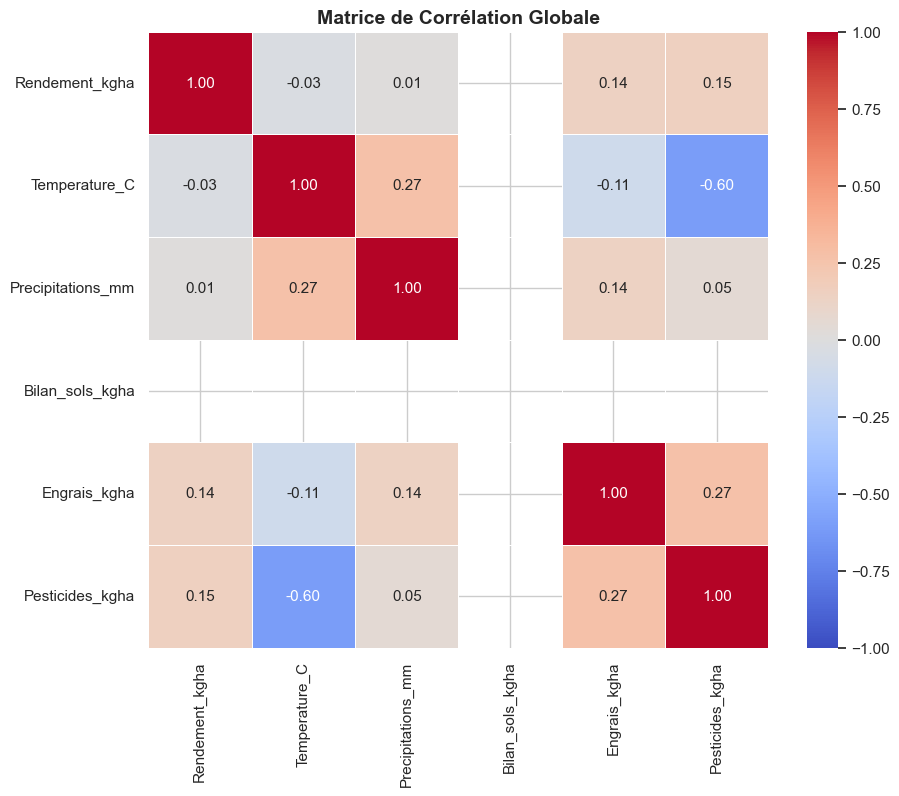

In [4]:
plt.figure(figsize=(10, 8))
corr = df_master[['Rendement_kgha', 'Temperature_C', 'Precipitations_mm', 'Bilan_sols_kgha', 'Engrais_kgha', 'Pesticides_kgha']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matrice de Corrélation Globale")
plt.show()

## 🌾 Relations non-linéaires fondamentales

L'agriculture dépend fortement des fenêtres climatiques optimales. Analysons l'influence de la température et des précipitations sur le rendement.

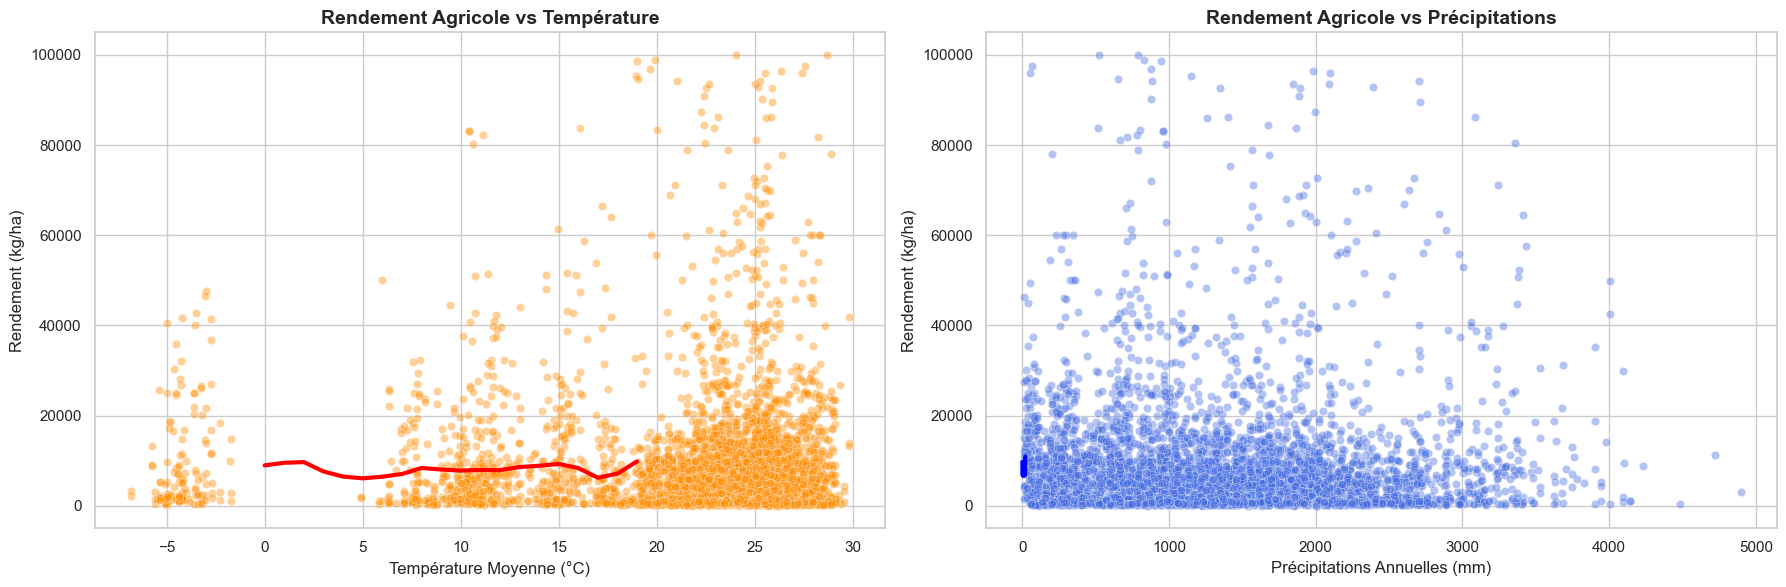

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Échantillon pour lisibilité du scatter
df_sample = df_master.sample(min(5000, len(df_master)), random_state=42)

sns.regress = False
sns.scatterplot(data=df_sample, x='Temperature_C', y='Rendement_kgha', alpha=0.4, ax=axes[0], color='darkorange')
sns.lineplot(data=df_master, x=pd.qcut(df_master['Temperature_C'], 20, labels=False, duplicates='drop'), y='Rendement_kgha', ax=axes[0], color='red', errorbar=None, linewidth=3)
axes[0].set_title("Rendement Agricole vs Température")
axes[0].set_xlabel("Température Moyenne (°C)")
axes[0].set_ylabel("Rendement (kg/ha)")

sns.scatterplot(data=df_sample, x='Precipitations_mm', y='Rendement_kgha', alpha=0.4, ax=axes[1], color='royalblue')
sns.lineplot(data=df_master, x=pd.qcut(df_master['Precipitations_mm'], 20, labels=False, duplicates='drop'), y='Rendement_kgha', ax=axes[1], color='blue', errorbar=None, linewidth=3)
axes[1].set_title("Rendement Agricole vs Précipitations")
axes[1].set_xlabel("Précipitations Annuelles (mm)")
axes[1].set_ylabel("Rendement (kg/ha)")

plt.tight_layout()
plt.show()

## ⚙️ Simulation Spatiale de la Couche 1 avec le Moteur Physique

Nous instancions le moteur physique `Layer1Engine` et générons toutes les caractéristiques et les 9 indicateurs cibles de simulation pour 3 biotopes contrastés du globe (Paris, Manaus et Le Caire).

In [6]:
engine = Layer1Engine(raw_dir='data/raw')

test_locations = [
    {"name": "Paris (Zone Tempérée)", "lat": 48.8566, "lon": 2.3522},
    {"name": "Manaus (Zone Équatoriale)", "lat": -3.1190, "lon": -60.0217},
    {"name": "Le Caire (Zone Aride)", "lat": 30.0444, "lon": 31.2357}
]

results = []
for loc in test_locations:
    res = engine.get_physical_features(loc["lat"], loc["lon"])
    res["Name"] = loc["name"]
    results.append(res)

df_sim = pd.DataFrame(results)
# Afficher les 9 cibles calculées
cols_targets = [
    'Name', 'predicted_yield_kgha', 'water_stress_index', 'koppen_geiger_class', 
    'flood_risk_index', 'soil_degradation_rate', 'fauna_herbivore_biomass_kg_km2', 
    'vector_suitability_index', 'local_heat_island_anomaly', 'soil_erosion_index'
]
df_sim[cols_targets]

c:\Users\alexi\Desktop\Swarm_Prediction\layer1_engine.py:133: DtypeWarning: Columns (0: other_fuel3) have mixed types. Specify dtype option on import or set low_memory=False.
  self._power_plants = pd.read_csv(path)
c:\Users\alexi\Desktop\Swarm_Prediction\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['Bilan_sols_kgha']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\alexi\Desktop\Swarm_Prediction\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['Bilan_sols_kgha']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\alexi\Desktop\Swarm_Prediction\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['Bilan_sols_kgha']. At least one non-missing value is needed for imputation with strateg

,Name,predicted_yield_kgha,water_stress_index,koppen_geiger_class,flood_risk_index,soil_degradation_rate,fauna_herbivore_biomass_kg_km2,vector_suitability_index,local_heat_island_anomaly,soil_erosion_index
0,Paris (Zone Tempérée),4219.63,0.000,C (Temperate),0.000,0.034,52.00,0.00,0.98,0.0043
1,Manaus (Zone Équatoriale),4791.80,0.000,A (Tropical),0.499,0.013,116.77,99.93,0.33,0.0111
2,Le Caire (Zone Aride),4297.97,0.836,B (Arid / Desert),0.646,0.053,2.57,0.48,1.47,0.0004


## 📊 Visualisation Comparative des Cibles par Biome

Comparons visuellement comment l'environnement impacte les indicateurs cibles majeurs de notre simulation de société.

C:\Users\alexi\AppData\Local\Temp\ipykernel_31616\3074097839.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sim, x='Name', y='predicted_yield_kgha', ax=axes[0,0], palette='viridis')
C:\Users\alexi\AppData\Local\Temp\ipykernel_31616\3074097839.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sim, x='Name', y='water_stress_index', ax=axes[0,1], palette='Blues_r')
C:\Users\alexi\AppData\Local\Temp\ipykernel_31616\3074097839.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sim, x='Name', y='vector_suitability_

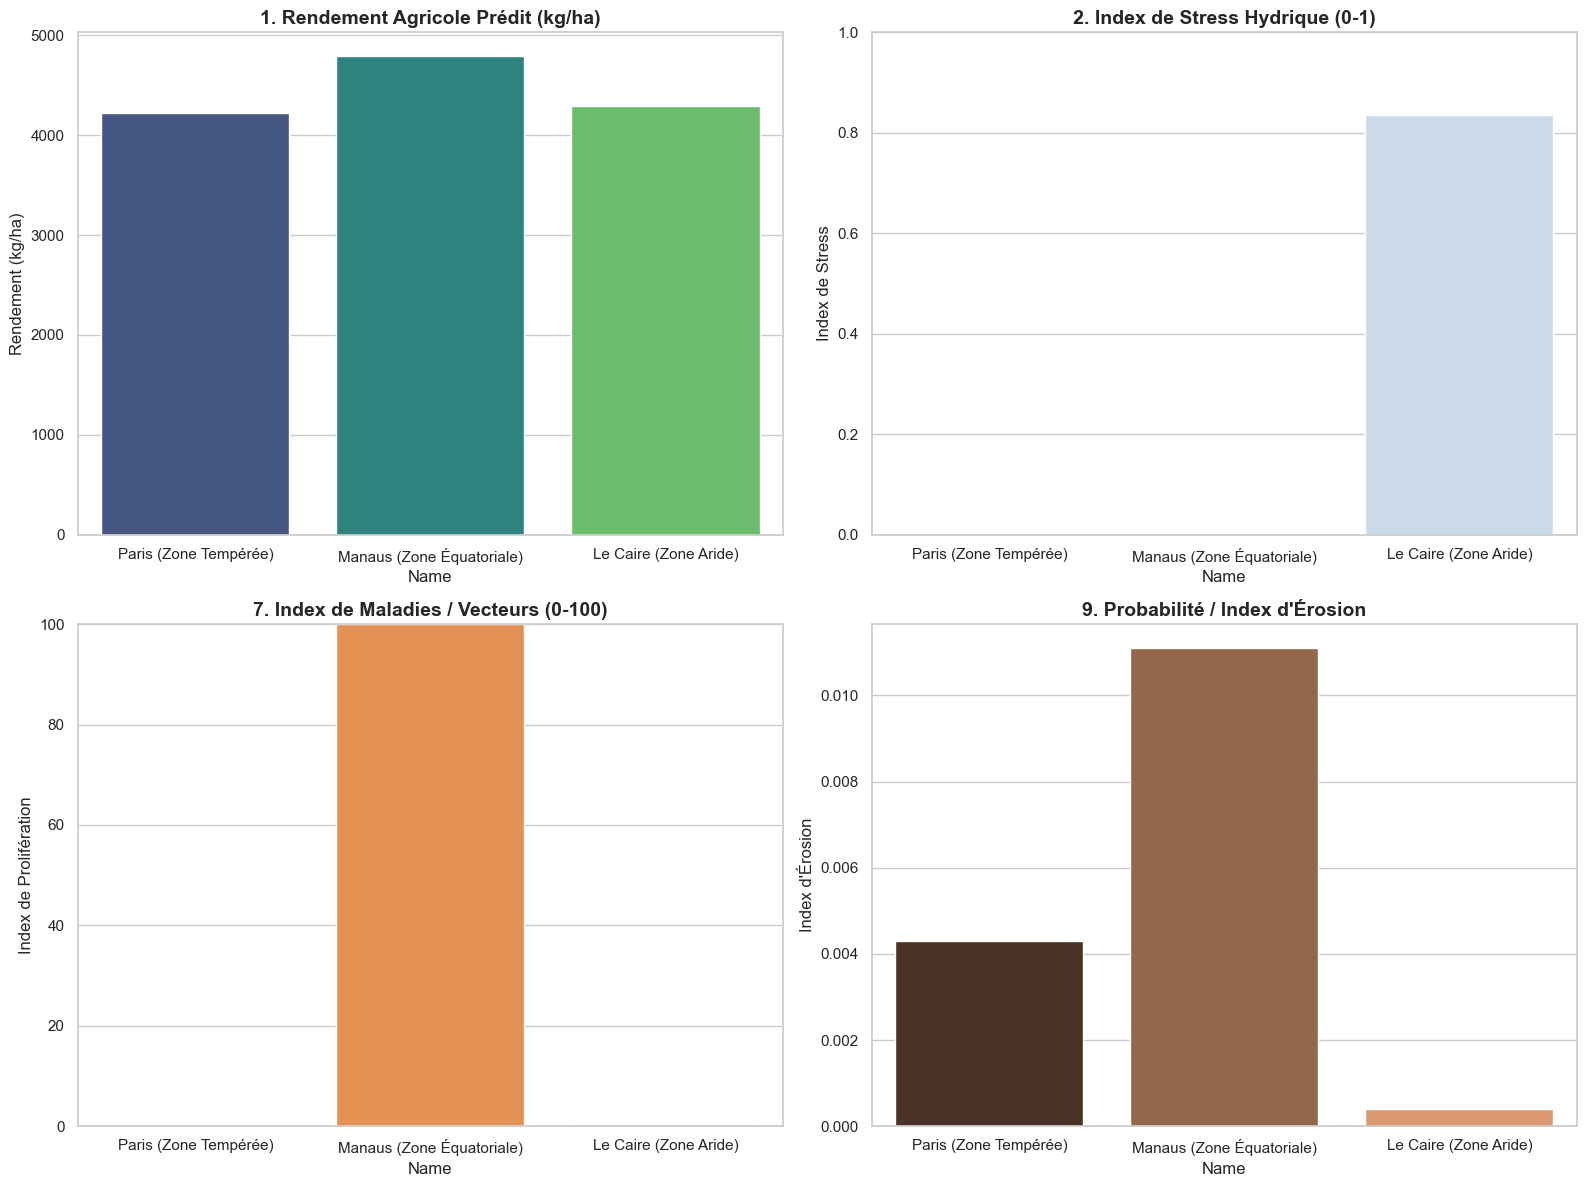

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=df_sim, x='Name', y='predicted_yield_kgha', ax=axes[0,0], palette='viridis')
axes[0,0].set_title("1. Rendement Agricole Prédit (kg/ha)")
axes[0,0].set_ylabel("Rendement (kg/ha)")

sns.barplot(data=df_sim, x='Name', y='water_stress_index', ax=axes[0,1], palette='Blues_r')
axes[0,1].set_title("2. Index de Stress Hydrique (0-1)")
axes[0,1].set_ylabel("Index de Stress")
axes[0,1].set_ylim(0, 1)

sns.barplot(data=df_sim, x='Name', y='vector_suitability_index', ax=axes[1,0], palette='Oranges')
axes[1,0].set_title("7. Index de Maladies / Vecteurs (0-100)")
axes[1,0].set_ylabel("Index de Prolifération")
axes[1,0].set_ylim(0, 100)

sns.barplot(data=df_sim, x='Name', y='soil_erosion_index', ax=axes[1,1], palette='copper')
axes[1,1].set_title("9. Probabilité / Index d'Érosion")
axes[1,1].set_ylabel("Index d'Érosion")

plt.tight_layout()
plt.show()

## 🎯 Conclusions de la Couche 1 pour la Civilisation

1. **Rendement & Alimentation** : La zone équatoriale (Manaus) offre de forts rendements potentiels dus aux précipitations, tandis que la zone aride (Le Caire) est fortement pénalisée par l'absence d'eau douce.
2. **Stress Hydrique** : L'eau douce et le bilan précipitations-evapotranspiration déterminent la viabilité économique locale. Le Caire subit un stress hydrique maximal.
3. **Maladies & Démographie** : Les zones chaudes et humides (Manaus) présentent un risque de vecteurs parasitaires (Malaria) maximal. Cela créera d'importantes barrières démographiques (surmortalité infantile) pour la Couche 2 (Démographie).
4. **Faunes & Ressources** : Les zones de forte NPP abritent d'importantes populations animales exploitables par les chasseurs-cueilleurs primitives.